[*********************100%***********************]  50 of 50 completed


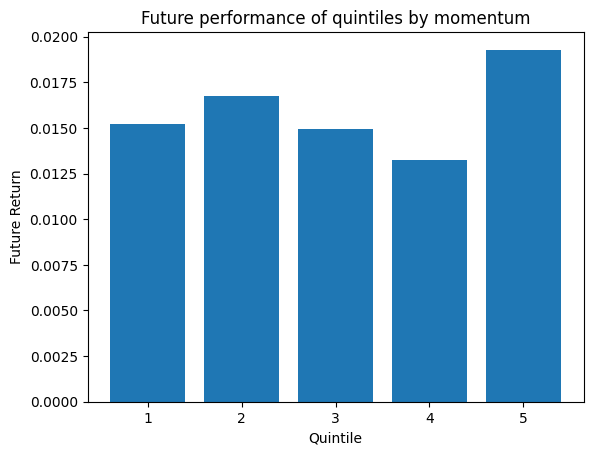

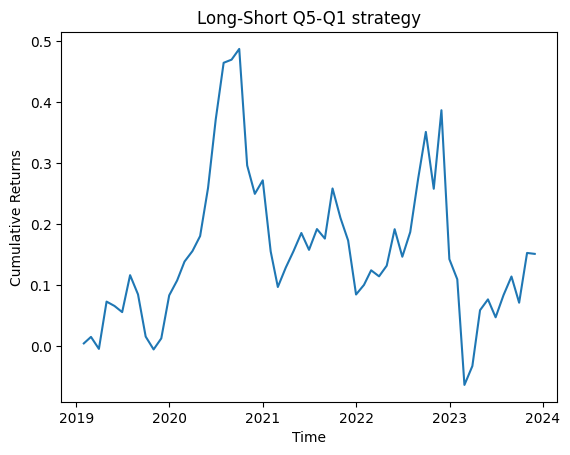

              mean       std    sharpe
quintile                              
1         0.015206  0.095831  0.158679
2         0.016758  0.077526  0.216158
3         0.014946  0.077875  0.191928
4         0.013227  0.075965  0.174117
5         0.019280  0.085581  0.225283


In [39]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -- Functions --------------------------------


# ── Universe ─────────────────────────────────────────────────────────
stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "JPM", "JNJ", "XOM",
    "UNH", "V", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO",
    "AVGO", "COST", "MCD", "WMT", "BAC", "TMO", "CSCO", "ACN", "NEE", "LIN",
    "ABT", "DHR", "TXN", "CRM", "VZ", "INTC", "QCOM", "AMD", "HON", "UPS",
    "PM", "MS", "GS", "BLK", "SPGI", "AXP", "CAT", "DE", "MMM", "RTX"
]

raw_data = yf.download(stocks, start="2018-01-01", end="2023-12-31")

close_prices = raw_data["Close"]

close_prices_monthly = close_prices.resample("ME").last()

returns_monthly = close_prices_monthly.pct_change()
momentum = (1 + returns_monthly).rolling(window=11).apply(np.prod, raw=True) - 1
momentum = momentum.shift(1)
results = []
valid_dates=momentum.dropna().index
for i, date in enumerate(valid_dates):
    if i == len(valid_dates) - 1: continue
    else:
        month_momentum = momentum.loc[date]
        month_momentum_quintile= pd.qcut(month_momentum, 5,  labels=[1, 2, 3, 4, 5])
        future_returns = returns_monthly.loc[valid_dates[i+1]]
        quintile_future_returns_table = pd.DataFrame({
    "quintile": month_momentum_quintile,
    "future_return": future_returns,
    "date": date
})
        results.append(quintile_future_returns_table)

all_results = pd.concat(results)
grouped_results=all_results.groupby("quintile")["future_return"].mean()

plt.bar(grouped_results.index, grouped_results.values)
plt.title("Future performance of quintiles by momentum")
plt.xlabel("Quintile")
plt.ylabel("Future Return")
plt.show()

Q5=all_results[all_results["quintile"] == 5]
monthly_quintile_returns = all_results.groupby(["date", "quintile"])["future_return"].mean()

q5_returns = monthly_quintile_returns.xs(5, level="quintile")
q1_returns = monthly_quintile_returns.xs(1, level="quintile")
long_short_returns = q5_returns - q1_returns

profit = (1 + long_short_returns).cumprod() - 1
plt.plot(profit)
plt.title("Long-Short Q5-Q1 strategy")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")
plt.show()
summary_table = all_results.groupby("quintile")["future_return"].agg(["mean", "std"])
summary_table["sharpe"] = summary_table["mean"] / summary_table["std"]
print(summary_table)

My research Question was whether high momentum predicts higher returns. I downloaded a universe of 50 US stocks, transformed them into monthly returns. Momentum of a stock in month m s defined by the returns of stock in months i-12 till i-2, an 11 month return skipping the previous month. Splitting momentum dataset into quintiles and comparing average returns of each quintile, I found that Q5 outperforms the Q1. Plotting a simple long-short strategy with Q5 long and Q1 short shows positive returns, although not extraordinary. Interesting finding is that the long-short strategy was significantly overperforming during covid in late 2020, reaching returns yearly returns of about 40-50%, shortly before falling back to below-market returns. Calculating sharpe for each quintile (using risk free rate of 0%), gives the quintile with highest sharpe to be Q5, supporting my previous results.
Main limitation of this project is the sub-optimal trading strategy and use of ultra-simplified model (i.e. RFR of 0%). The results do not point to significant returns, hence the strategy is not effective. Other limitations include survivorship bias, all stocks that are "now" popular and hence included in the universe survived the time period, all stocks that crashed are either not listed anymore or simply not in the universe duo to low relevance.No transaction costs and limited amount of stocks in universe also suggest that the results might not interpret the reality in the best way. The next step in this research would be to either increase the universe, try to find more suitable split(quintiles into 1/8ths or similar) and create a more sophisticated trading strategy.
